In [13]:
import mat73
import numpy as np
from matplotlib import pyplot as plt
from scipy.constants import h, c as c0,e

from qnmsc.surmof_cavity import ag_surmof_cavity_smat
from qnmsc.track_qnms import track_qnms
from qnmsc.plot_trajectories import load_data, select_modes
from qnmsc.plot_splitting import plot_splitting
from qnmsc.mpl_config import um, inv_um, mm, config

config()
k0_to_eV = 1e6*h*c0/e/(2*np.pi)

%autoreload

In [14]:
data_dict = mat73.loadmat("assets/in/data_figure6/Data_SMA.mat")
kn = data_dict['kn']
thickness_surmof = np.array([T[0][1] for T in kn['T']])
Nt = len(thickness_surmof)
poles = np.sort(kn['poles'][0][0])[-3:] * k0_to_eV

In [15]:
q_rse   = np.zeros((Nt, 4), dtype=complex)
gcoeff  = np.zeros((Nt, 3), dtype=complex)
kcshift = np.zeros((Nt, 1), dtype=complex)
kc      = np.zeros((Nt, 1), dtype=complex)

for i in range(Nt):
    q_rse[i,:] = np.sort(kn['knNew'][i][0])

    gcoeff[i,:] = kn['coupl_coeffs'][i][0][::-1]
    kcshift[i] = kn['knShift'][i][0]
    kc[i] = kn['knVal'][i][0][0]

q_rse   *= k0_to_eV
gcoeff  *= k0_to_eV
kcshift *= k0_to_eV
kc      *= k0_to_eV

In [16]:
on_resonance_idx = np.argmin(np.abs(kc.real[:,None]-poles.real[None,:]), axis=0).ravel()

In [17]:
X_rse = thickness_surmof*1e6

In [18]:
hbar_omega = np.linspace(1, 2.5, 401)
inv_d = np.linspace(0.6, 16, 1021)
E, T = np.meshgrid(hbar_omega, 1/inv_d)

smat = ag_surmof_cavity_smat( 
  E, T
)

from matplotlib.colors import ListedColormap
a = 0.7
my_cmap = plt.cm.viridis(np.arange(plt.cm.viridis.N))
my_cmap[:,0:3] *= a 
my_cmap = ListedColormap(my_cmap)

QNMs at rabi: [1.457-0.056j 1.799-0.014j 1.847-0.014j 2.098-0.092j]


/mnt/data/jd/code/projects/agsurmof/qnmsc/inverse_eigenproblem.py:50: RuntimeWarning: invalid value encountered in divide
  fac = -1/(oms-evs)
/mnt/data/jd/code/projects/agsurmof/qnmsc/plot_splitting.py:152: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=5, labelcolor=c_font, loc=legend_loc)
/mnt/data/jd/code/projects/agsurmof/qnmsc/plot_splitting.py:182: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=5, title="Material Resonances", loc="lower right", frameon=True)


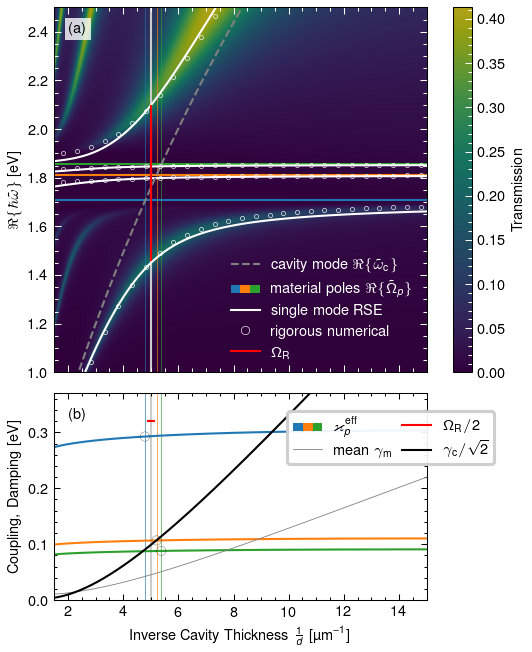

In [19]:
from qnmsc.mpl_config import MulticolorPatch, MulticolorPatchHandler

inv_d = True
Param = 1/X_rse if inv_d else X_rse
on_resonance_param = Param[on_resonance_idx]

domain = [0.7-0.7j, 5.0+0.05j]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(90*mm, 110*mm), height_ratios=[3,1.7], constrained_layout=True)

plt.sca(axs[0])
plt.pcolormesh(1/T if inv_d else T, E, np.abs(smat['in', 'out'])**2, zorder=-2, rasterized=True, shading='gouraud', cmap=my_cmap)
cbar = plt.colorbar(label="Transmission")

plt.tick_params(which='both', color="white")
cbar.ax.tick_params(which='both', color="white")

for which, length, width in zip(['major', 'minor'], [3.5, 2], [0.5,0.5]):
  plt.tick_params(which=which, length=length, width=width)
  cbar.ax.tick_params(which=which, length=length, width=width)

fig, axs, om_os, Cs, param = plot_splitting(
    1,3,1,1,domain, inv_d=inv_d, return_fit=True, plot_dots=False, n_interp=200, 
    axs=axs, ylim=(min(hbar_omega), max(hbar_omega)),
    plot_cavity_mode=False, c_higher=[0,0,0,0], c_fundamental="white", 
    plot_extracted_coupling=False, scatter_numerical=True)

for ax in axs:
  for i, on_res_p in enumerate(on_resonance_param):
    ax.axvline(on_res_p, ls="-", color=f"C{i}", lw=0.3, zorder=-1)

plt.sca(axs[1])
#plt.yscale('log')
#plt.ylim(0.005, 0.4)
kappa = np.sqrt(np.abs(gcoeff*poles))
for i, (on_res_p, on_res_i) in enumerate(zip(on_resonance_param, on_resonance_idx)):
  plt.scatter([on_res_p], [kappa[on_res_i, i]], color=f"C{i}", facecolor='none', edgecolor="k", zorder=3, s=20)

plt.ylim(0, 0.37)

plt.plot(Param, kappa)
# plt.plot(Param, np.sqrt(np.real(-gcoeff*poles)), color="k") # -> mostly real, but not fully -> dissipative coupling
#for i, gamma in enumerate(-poles.imag.T):
  #plt.axhline(gamma, ls="--", color=f"C{i}")
  #plt.plot(Param, gamma, color=f"C{i}", ls="--")


plt.plot(Param, np.mean(-q_rse.imag, axis=-1), lw=0.4, color="gray", label="mean $\gamma_\mathrm{m}$")
plt.plot([],[], color="r", label=r"$\Omega_\mathrm{R}/2$")
#plt.plot(Param, -kc.imag, "gray", ls="--", label=r"$\gamma_\mathrm{c}$")
plt.plot(Param, -kc.imag/np.sqrt(2), ls="-", color="k", label=r"$\gamma_\mathrm{c}/\sqrt{2}$")

#plt.gca().get_legend().remove()
plt.ylabel(r"Coupling, Damping [eV]")

# ------ get the legend-entries that are already attached to the axis
h, l = axs[1].get_legend_handles_labels()

# ------ append the multicolor legend patches
h.insert(0, MulticolorPatch(['C0', 'C1', 'C2']))
l.insert(0, r"$\varkappa^\mathrm{eff}_p$")

# h.append(MulticolorPatch(['C0', 'C1', 'C2'], width_scaling=0.7, height_scaling=0.7**2))
# l.append(r"$\gamma_p$")

# ---- Lock the layout here ----
# Force layout to be c\tilde{\Omega}_puted
fig.canvas.draw()
# Disable constrained layout (positions are now frozen)
fig.set_constrained_layout(False)

legend = plt.legend(h, l, loc="upper right", frameon=True, 
      handler_map={MulticolorPatch: MulticolorPatchHandler()}, ncol=2, 
      bbox_to_anchor=(1.2, 0.95), columnspacing=0.7)
legend.get_frame().set_alpha(0.93) 
legend.get_frame().set_linewidth(1.5)

if inv_d:
  plt.xlim(1.5, 15)
else:
  plt.xlim(0.05, 0.5)

plt.sca(axs[0])
plt.plot(Param, q_rse.real, color="white")
#plt.plot(Param, kcshift.real)
plt.plot(Param, kc.real, "gray", ls="--")


plt.plot([], [], color="gray", ls="--", label=r"cavity mode $\Re\{\tilde{\omega}_\mathrm{c}\}$")
plt.plot([], [], color="white", label="single mode RSE")
plt.plot([], [], label="rigorous numerical", mec="white", marker="o", mfc="none", ls="none", ms=4)
plt.plot([], [], color="r", label="$\Omega_\mathrm{R}$")

# ------ get the legend-entries that are already attached to the axis
h, l = axs[0].get_legend_handles_labels()

# ------ append the multicolor legend patches
h.insert(1, MulticolorPatch(['C0', 'C1', 'C2']))
l.insert(1, r"material poles $\Re\{\tilde{\Omega}_p\}$")

plt.legend(h, l, handler_map={MulticolorPatch: MulticolorPatchHandler()}, labelcolor="white", loc="lower right")

for j, ax in enumerate(axs):
  letter = chr(ord("a")+j)
  ax.annotate(
        f" ({letter})",
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+1, -1), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif',
        bbox=dict(facecolor=(1,1,1,0.8), edgecolor='none', pad=2.0))
    
plt.savefig("out/SMA_RSE.pdf", bbox_inches="tight")

$$
a_m^2 = \frac{1}{1 + \sum^P \frac{-\tilde{\Omega}_p}{(\tilde{\omega}_m - \tilde{\Omega}_p)^2} g_p + \frac{\tilde{\omega}_\mathrm{c}-\tilde{\omega}_m}{\tilde{\omega}_m}\mathrm{I}_\mathrm{surf, c}}
$$

In [20]:
bc_poles = poles[None, :, None]
bc_q_rse = q_rse[:, None, :]
bc_gcoeff = gcoeff[..., None]
summand = -bc_gcoeff*(bc_poles/(bc_q_rse-bc_poles)**2)

In [21]:
Sigma_P = np.sum(summand, axis=-2)

In [22]:
a_m = np.sqrt(1/(1+Sigma_P))

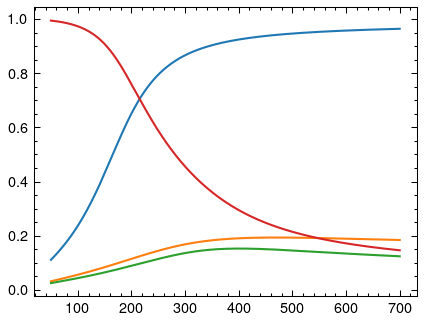

In [23]:
plt.plot(thickness_surmof*1e9, np.abs(a_m))

In [75]:
h_m = 1-np.abs(a_m)**2

In [77]:
A_mp = np.abs(a_m[:, None, :])**2 * np.abs(bc_gcoeff)**2/np.abs(bc_q_rse-bc_poles)**2
A_mp = A_mp.swapaxes(-1, -2)

In [78]:
z_p = [np.linalg.lstsq(A_mp[i], h_m[i]) for i in range(len(thickness_surmof))]

In [79]:
n_p_from_norm = [1/np.sqrt(z_i[0]) for z_i in z_p]
residuals = [z_i[1] for z_i in z_p]

In [80]:
n_p_est = (np.sqrt(gcoeff/poles))

Text(0.5, 0, 'SURMOF Thickness (nm)')

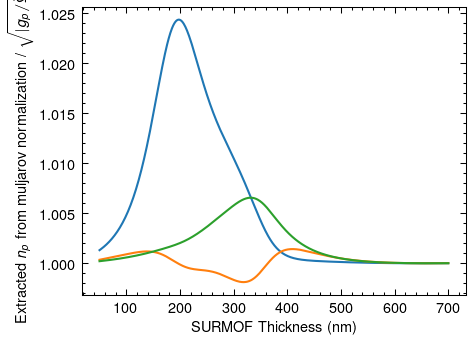

In [110]:
plt.plot(thickness_surmof*1e9, n_p_from_norm/np.abs(n_p_est))
plt.ylabel(r"Extracted $n_p$ from muljarov normalization / $\sqrt{|g_p/\tilde{\Omega}_p|}$")
plt.xlabel("SURMOF Thickness (nm)")

In [82]:
b_pm = a_m[:, None, :] / np.array(n_p_from_norm)[:, :, None] * (bc_gcoeff/(bc_q_rse-bc_poles))

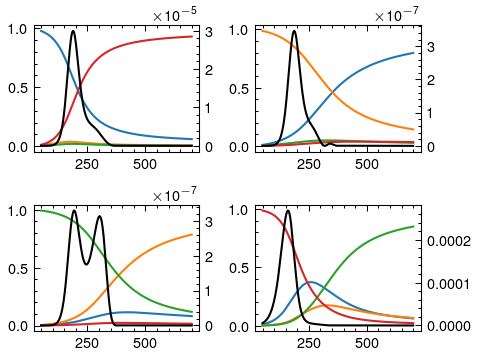

In [90]:
for m in range(b_pm.shape[2]):
  plt.subplot(221+m)
  plt.plot(thickness_surmof*1e9, np.abs(b_pm[..., m])**2)
  plt.plot(thickness_surmof*1e9, np.abs(a_m[..., m])**2)

  residual = np.abs(np.sum(np.abs(b_pm[..., m])**2, axis=-1) + np.abs(a_m[..., m])**2 -1)**2
  plt.twinx()
  plt.plot(thickness_surmof*1e9, np.abs(residual), color="k")
plt.tight_layout()

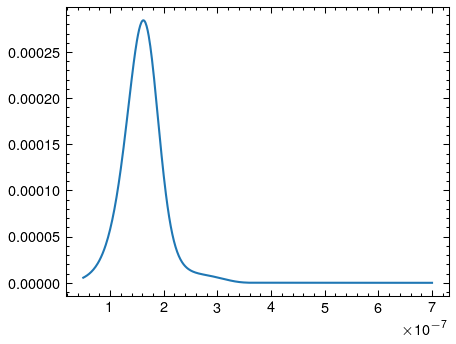

In [89]:
plt.plot(thickness_surmof, residuals)
# plt.plot(thickness_surmof, np.linalg.norm(h_m, axis=-1))

In [97]:
manual_q = []
evecs = []
left_evecs = []
use_norm = 'OmG' # 'OmG' 'P'
norm_fac = 1

for idx_freq in range(Nt):
  gs = gcoeff[idx_freq]
  H = np.zeros([len(poles)+1]*2, dtype=complex)
  
  if use_norm=='muljarov':
    n_p = n_p_from_norm[idx_freq]
  elif use_norm=='OmG':
    n_p = (np.sqrt(gs/poles) * norm_fac) 
  else: 
    n_p = np.ones_like(gs)*norm_fac
  for p, g in enumerate(gs):
      H[p+1, 0] = g/n_p[p]
      H[0, p+1] = -n_p[p]*poles[p]
      H[p+1, p+1] = poles[p]
  H[0, 0] = kcshift[idx_freq][0]

  eigenval, eigenvec = np.linalg.eig(H)
  sorter = np.argsort(eigenval)
  eigenval = eigenval[sorter]
  eigenvec = eigenvec[:, sorter]
  evecs.append(eigenvec)

  left_evals, left_evecs_ = np.linalg.eig(H.conj().T)
  left_evecs_ = left_evecs_.conj()
  left_sorter = np.argsort(left_evals)
  left_evals = left_evals[left_sorter]
  left_evecs_ = left_evecs_[:, left_sorter]
  left_evecs.append(left_evecs_)
  
  manual_q.append(eigenval)
manual_q = np.array(manual_q)
evecs = np.array(evecs)
left_evecs = np.array(left_evecs)

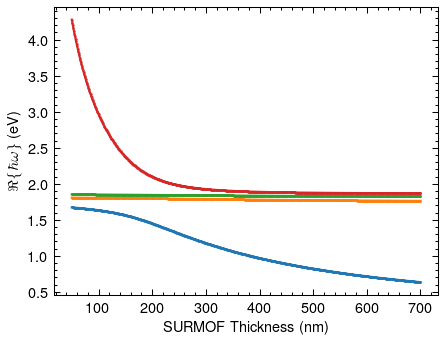

In [98]:
plt.figure()
plt.plot(thickness_surmof*1e9, q_rse.real, label="RSE")
for i in range(4):
    plt.scatter(thickness_surmof*1e9, manual_q[:, i].real, label="Manual", s=1)

plt.xlabel("SURMOF Thickness (nm)")
plt.ylabel("$\Re\{\hbar \omega\}$ (eV)")
plt.savefig("out/modes_for_hopfield.png", dpi=600)

In [106]:
mul_evec = np.concat([a_m[:, None, :], b_pm], axis=1)

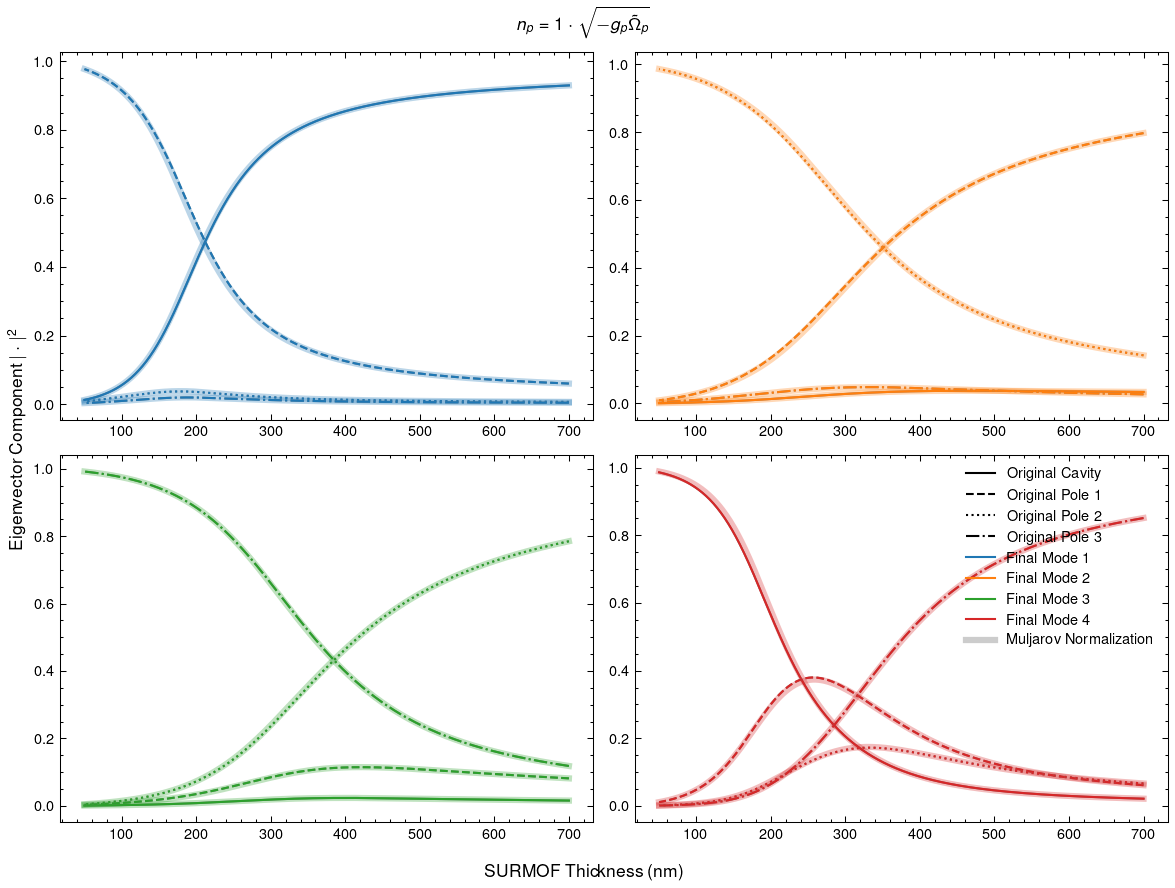

In [114]:
fig = plt.figure(figsize=(8, 6))
ls = ["-", "--", ":", "-."]
for i in range(4):
    for j in range(4):
        plt.subplot(221+j)
        plt.plot(thickness_surmof*1e9, np.abs(left_evecs[:, i, j])**2, color="gray", ls=ls[i])
        plt.plot(thickness_surmof*1e9, np.abs(evecs[:, i, j])**2, color=f"C{j}", ls=ls[i])

        plt.plot(thickness_surmof*1e9, np.abs(mul_evec[:, i, j])**2, color=f"C{j}", lw=3, alpha=0.3)

for i in range(4):
    if i==0:
        label = f"Original Cavity"
    else:
      label=f"Original Pole {i}"

    plt.plot([],[], ls=ls[i], color="k", label=label)
for j in range(4):
    label=f"Final Mode {j+1}"

    plt.plot([],[], color=f"C{j}", label=label)
plt.plot([], [], color="gray", lw=3, alpha=0.4, label="Muljarov Normalization")

fig.supxlabel("SURMOF Thickness (nm)")
fig.supylabel("Eigenvector Component $|\cdot|^2$")
plt.legend(loc="upper right")

if use_norm == 'muljarov':
  fig.suptitle(rf"$n_p$ from Muljarov normalization")
elif use_norm=='OmG':
  fig.suptitle(rf"$n_p = {norm_fac}\cdot\sqrt{{- g_p \tilde{{\Omega}}_p}}$")
else:
  fig.suptitle(rf"$n_p = {norm_fac}$")

plt.tight_layout()
plt.savefig(f"out/hopfield_n{use_norm}_{norm_fac}.png", dpi=600)
